### 02_eda

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Feature-wise class-normalized distribution analysis (equal-width-binning-based)**
</div>

In [ ]:
def plot_target_distribution(data, interval_feature, target_feature, bins=10):
    # Create bins for the interval feature
    data['interval_bins'] = pd.cut(data[interval_feature], bins=bins)
    
    # Calculate the number of observations per bin
    counts = data['interval_bins'].value_counts().sort_index()
    
    # Calculate the proportion of target class = 1 per bin
    proportions = data[data[target_feature] == 1].groupby('interval_bins').size() / counts
    
    # Create a DataFrame for plotting
    plot_data = pd.DataFrame({'Counts': counts, 'Proportion': proportions}).fillna(0)
    
    # Plot the distribution
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Plot the counts
    plot_data['Counts'].plot(kind='bar', color='skyblue', ax=ax1, position=1, width=0.25, ylim=(0, data.shape[0]*1.1))
    ax1.set_ylabel('Number of Observations')
    ax1.set_xlabel(interval_feature)
    ax1.set_title(f'Distribution of {target_feature} in {interval_feature} Bins')
    ax1.set_xticklabels(plot_data.index.astype(str), rotation=45)

    # Create a second y-axis for the proportion
    ax2 = ax1.twinx()
    plot_data['Proportion'].plot(kind='bar', color='lightsalmon', ax=ax2, position=0, width=0.25, ylim=(0, proportions.max()*1.25))
    ax2.set_ylabel(f'Proportion of {target_feature} = 1')

    # Add legend
    ax1.legend(['Counts'], loc='upper left')
    ax2.legend([f'Proportion of {target_feature} = 1'], loc='upper right')
    plt.grid(False)

    plt.show()
    data.drop(columns=['interval_bins'], inplace=True, errors='ignore')


def plot_target_distribution_equal(data, interval_feature, target_feature, bins=10):
    # Create quantile-based bins for the interval feature
    data['interval_bins'] = pd.qcut(data[interval_feature], q=bins, duplicates='drop')
    
    # Calculate the number of observations per bin
    counts = data['interval_bins'].value_counts().sort_index()
    
    # Calculate the proportion of target class = 1 per bin
    proportions = data[data[target_feature] == 1].groupby('interval_bins').size() / counts
    
    # Create a DataFrame for plotting
    plot_data = pd.DataFrame({'Counts': counts, 'Proportion': proportions}).fillna(0).reset_index()
    
    # Plot the distribution
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Plot the counts
    plot_data['Counts'].plot(kind='bar', color='skyblue', ax=ax1, position=1, width=0.2, ylim=(0, data.shape[0]*1.1))
    ax1.set_ylabel('Number of Observations')
    ax1.set_xlabel(interval_feature)
    ax1.set_title(f'Distribution of {target_feature} in {interval_feature} Bins')
    ax1.set_xticklabels(plot_data['interval_bins'].astype(str), rotation=45)

    # Create a second y-axis for the proportion
    ax2 = ax1.twinx()
    plot_data['Proportion'].plot(kind='bar', color='lightsalmon', ax=ax2, position=0, width=0.2, ylim=(0, proportions.max()*1.25))
    ax2.set_ylabel(f'Proportion of {target_feature} = 1')

    # Add legend
    ax1.legend(['Counts'], loc='upper left')
    ax2.legend([f'Proportion of {target_feature} = 1'], loc='upper right')

    plt.grid(False)
    plt.show()
    data.drop(columns=['interval_bins'], inplace=True, errors='ignore')

TARGET distribution:


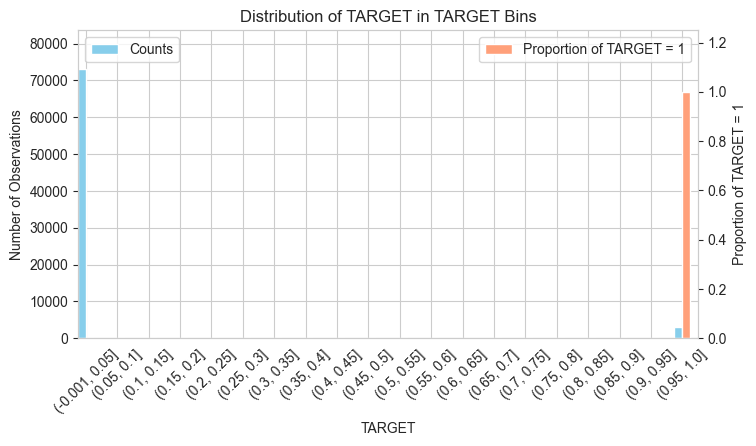

num_meses_var5_ult3 distribution:


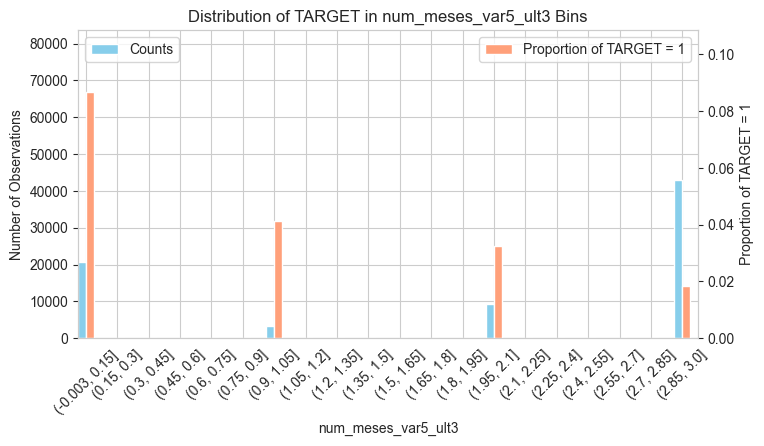

ind_var30 distribution:


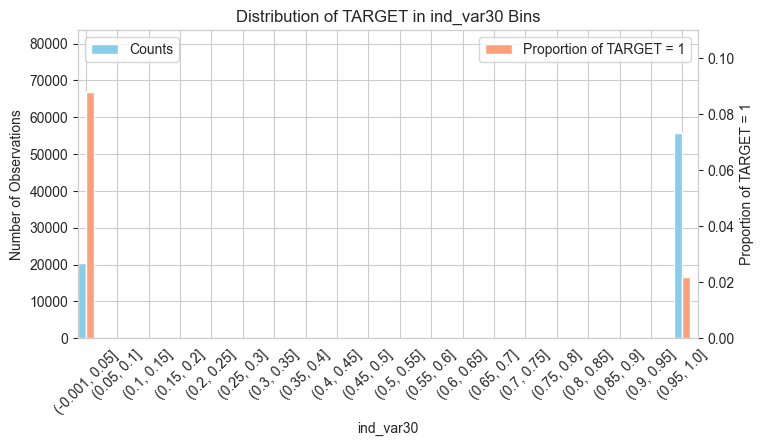

num_var4 distribution:


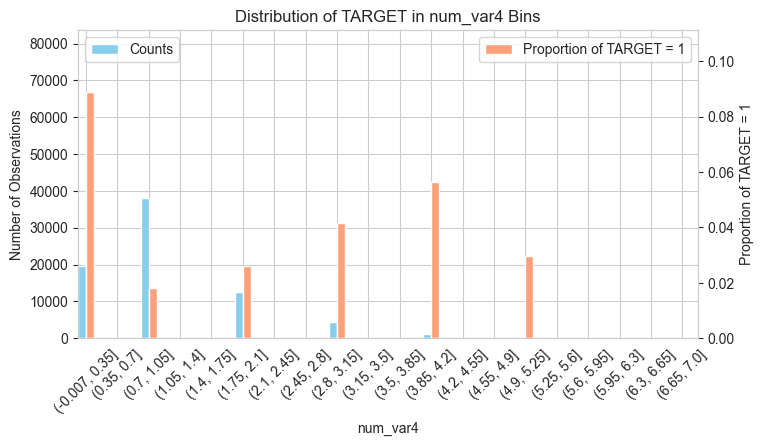

saldo_medio_var5_ult3 distribution:


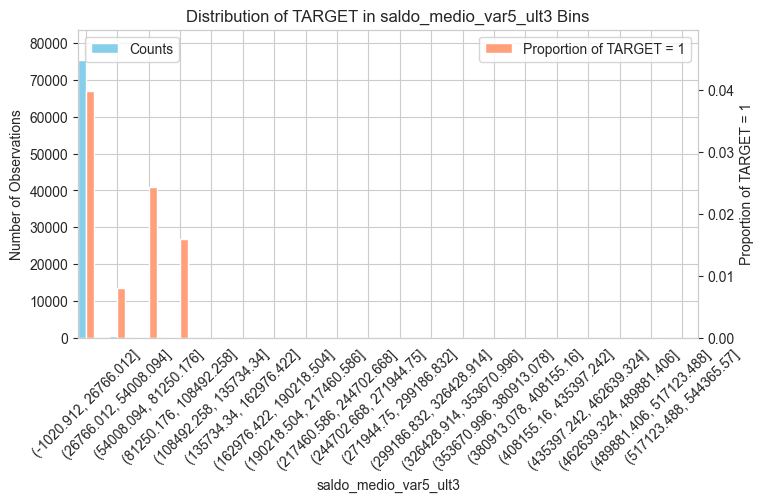

saldo_medio_var5_hace3 distribution:


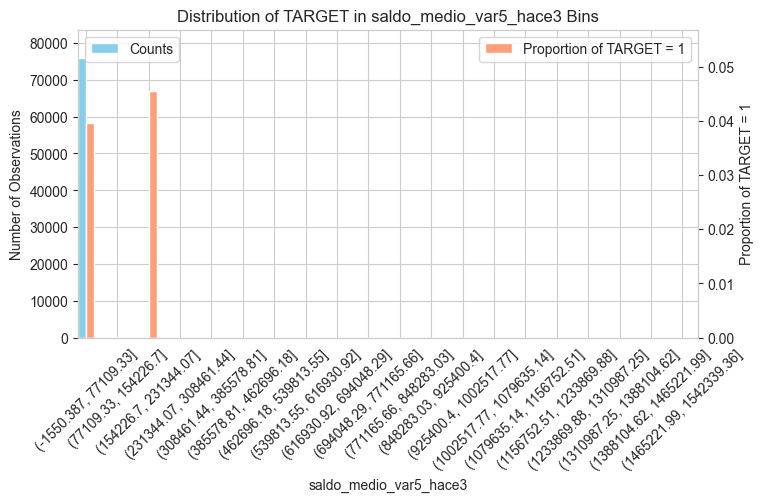

saldo_var30 distribution:


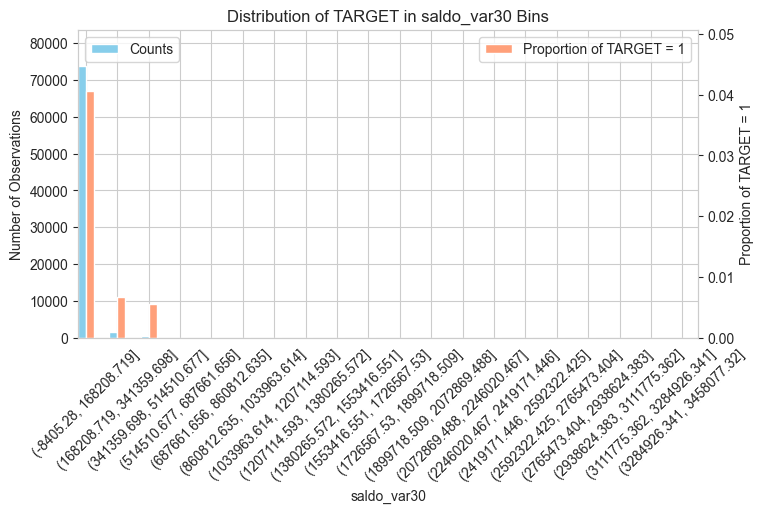

var15 distribution:


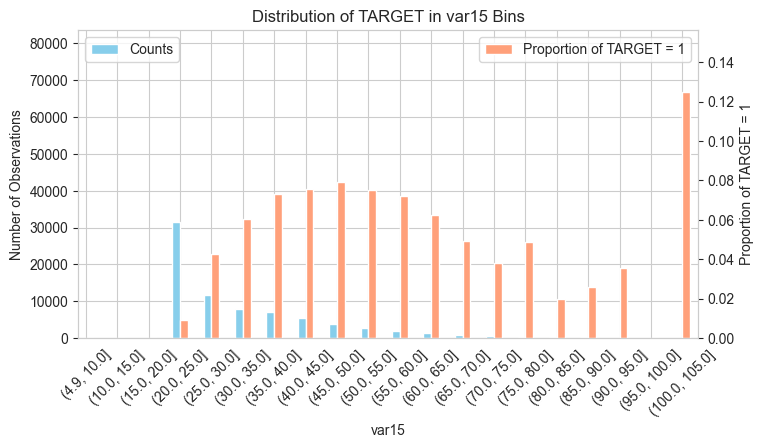

num_var30 distribution:


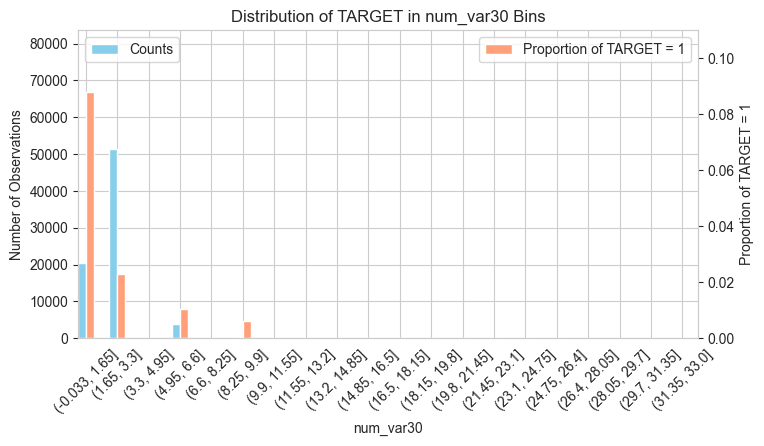

saldo_medio_var5_hace2 distribution:


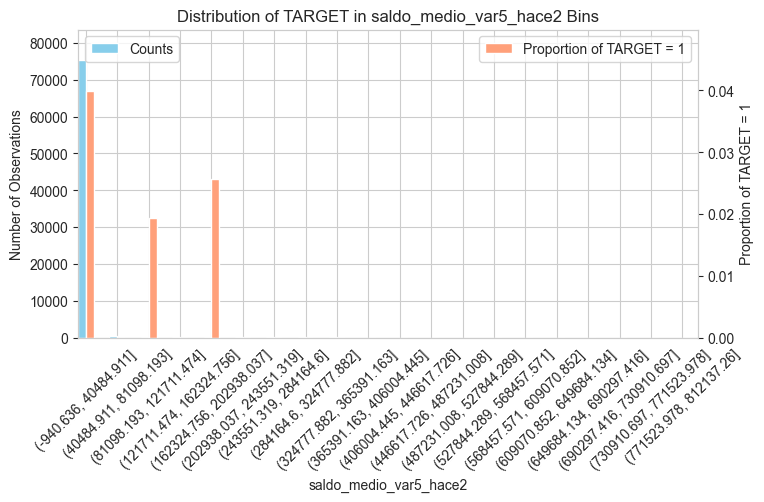

num_var42 distribution:


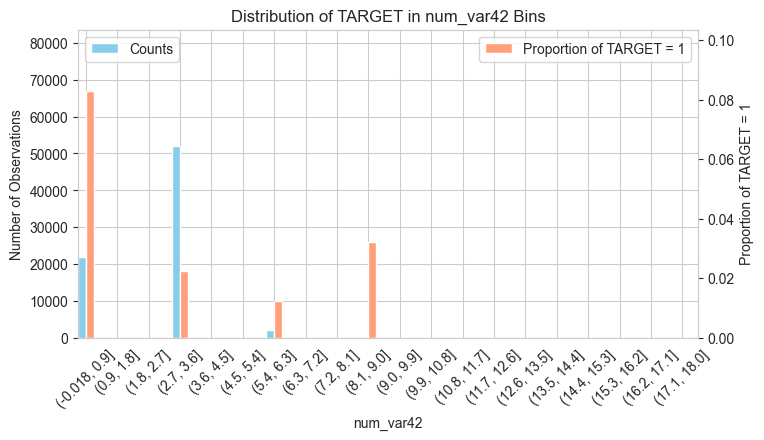

saldo_var5 distribution:


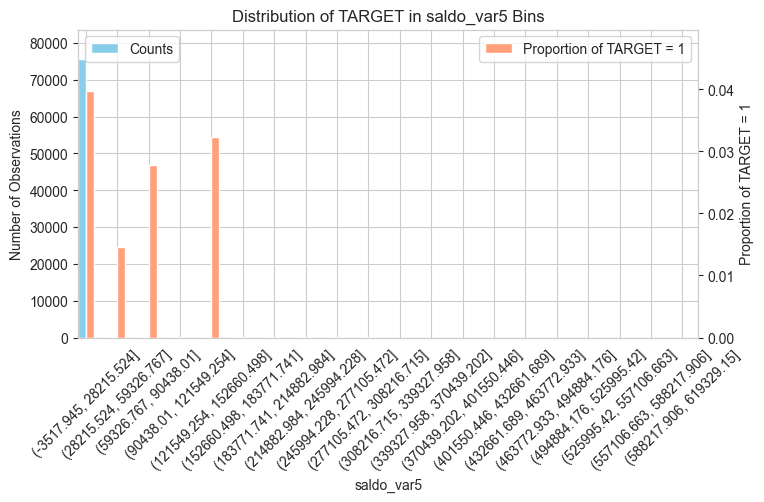

saldo_medio_var5_ult1 distribution:


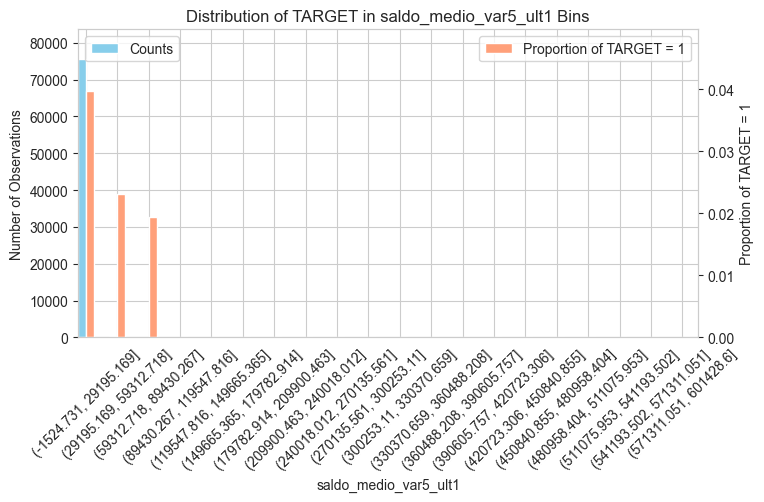

num_var5 distribution:


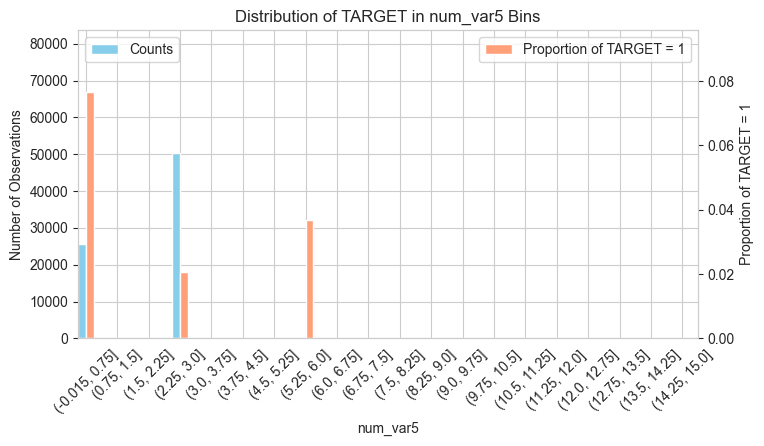

var36 distribution:


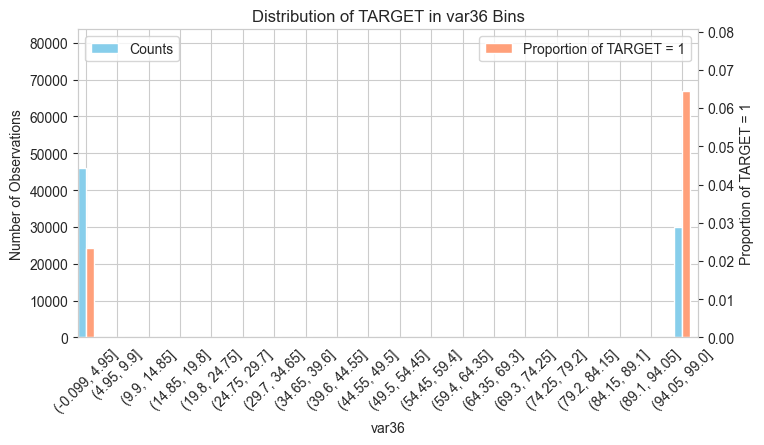

num_meses_var39_vig_ult3 distribution:


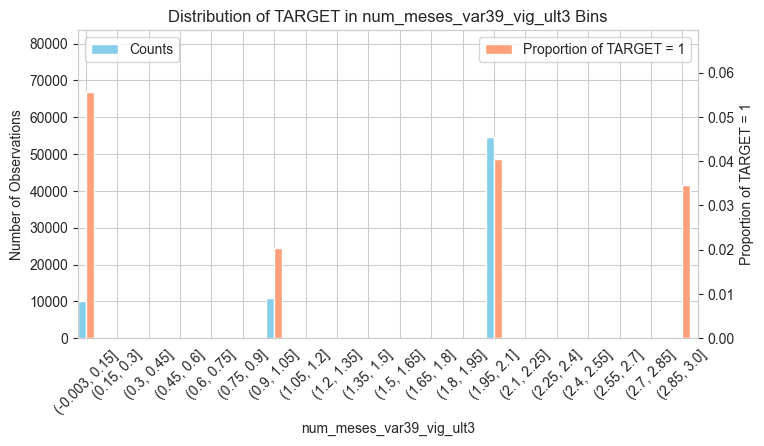

var38 distribution:


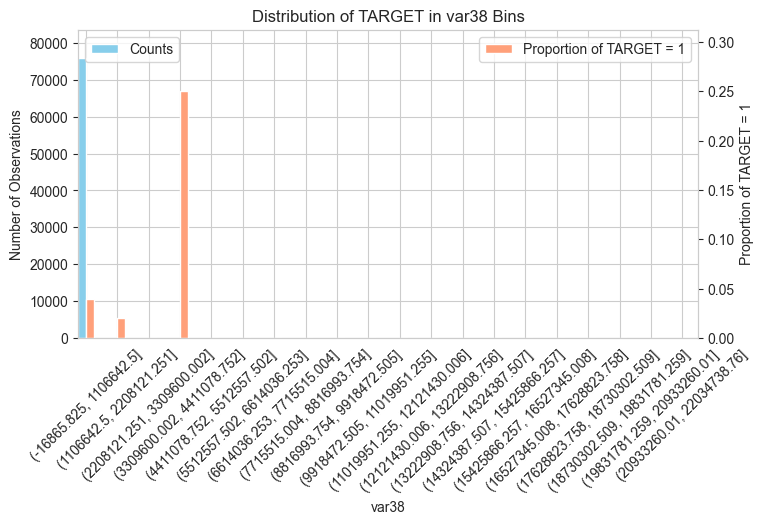

num_var12_0 distribution:


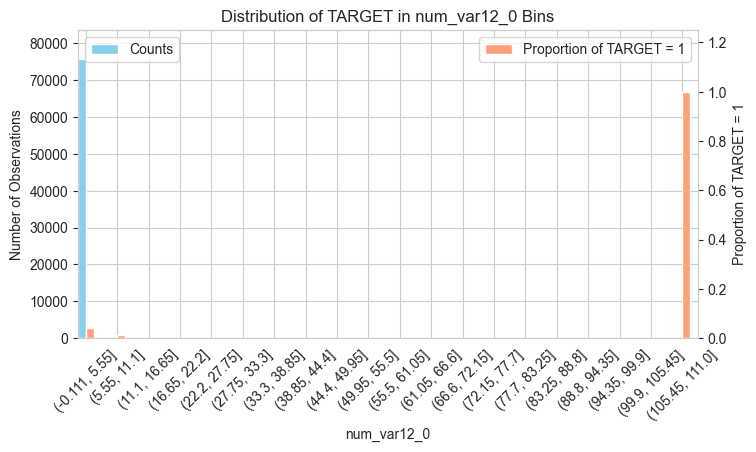

ind_var12_0 distribution:


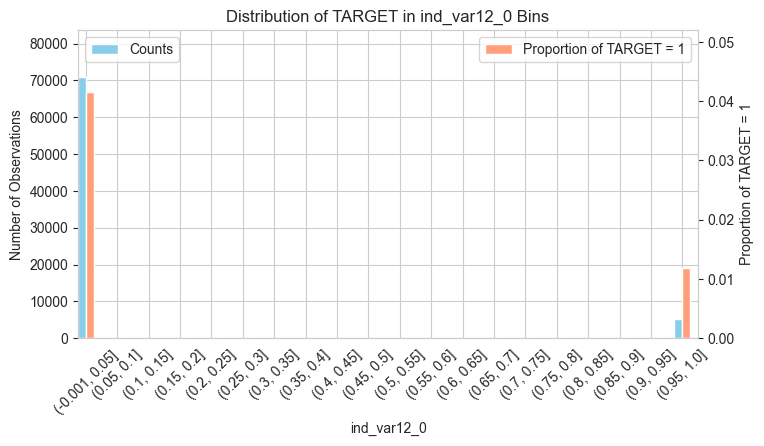

saldo_var13 distribution:


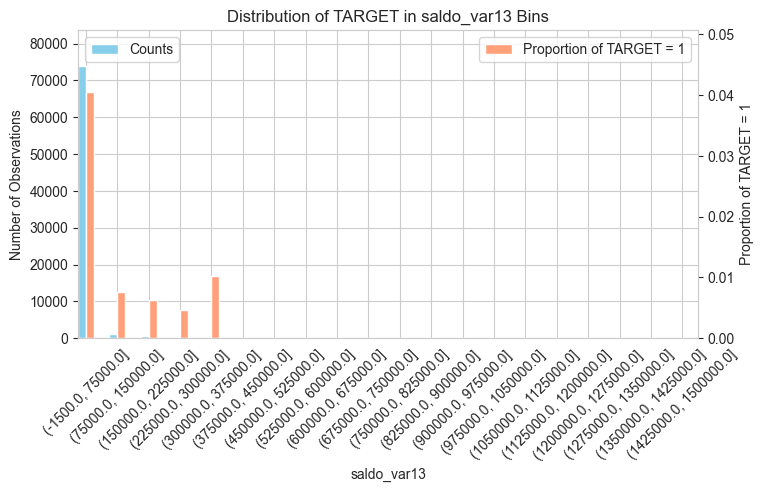

ind_var39_0 distribution:


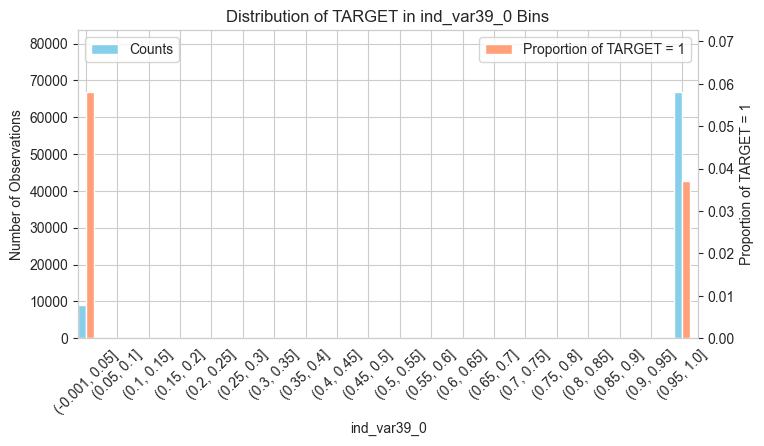

num_var24_0 distribution:


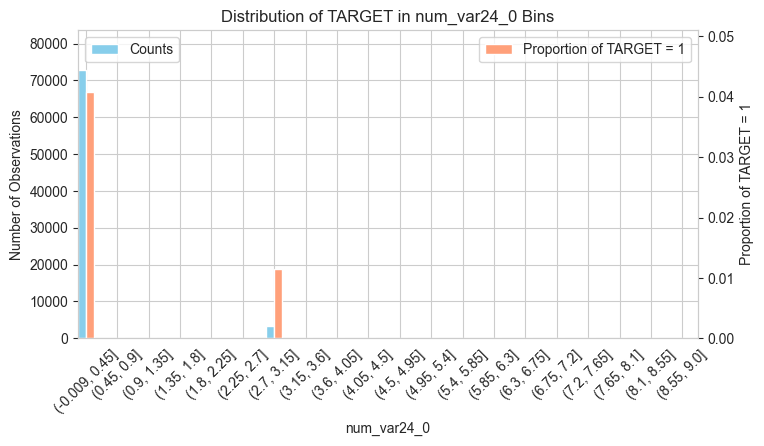

num_var42_0 distribution:


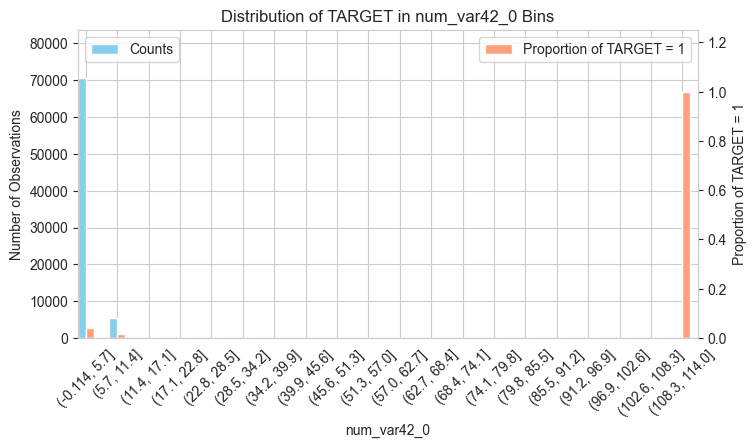

num_var12 distribution:


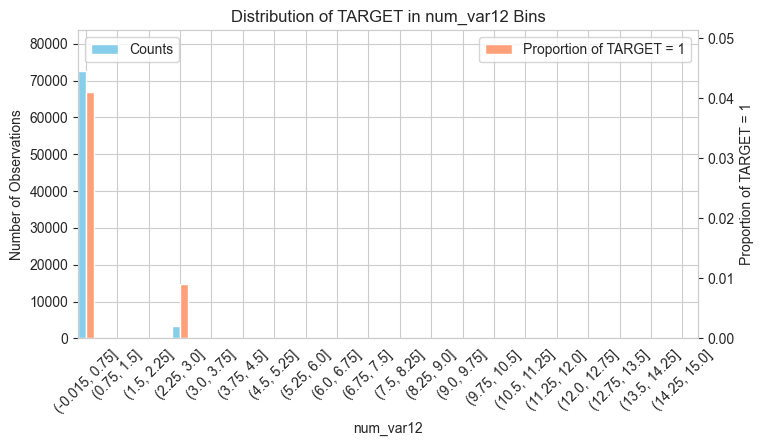

ind_var13_corto_0 distribution:


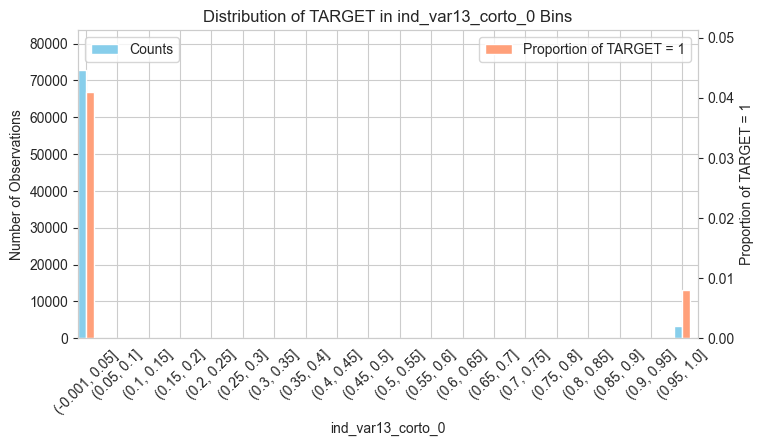

num_var45_ult1 distribution:


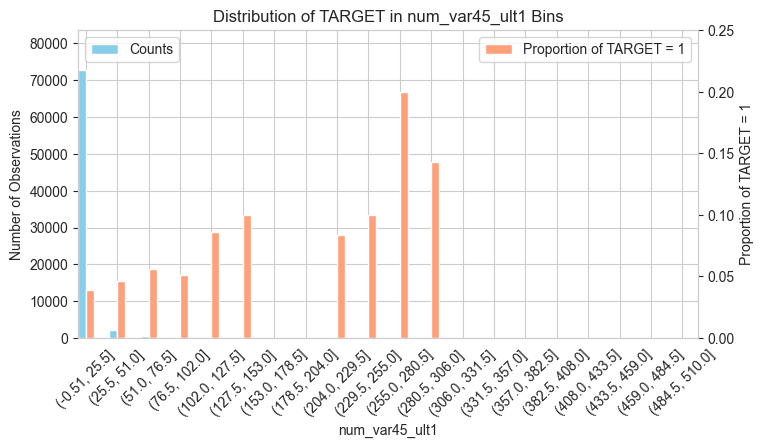

num_meses_var8_ult3 distribution:


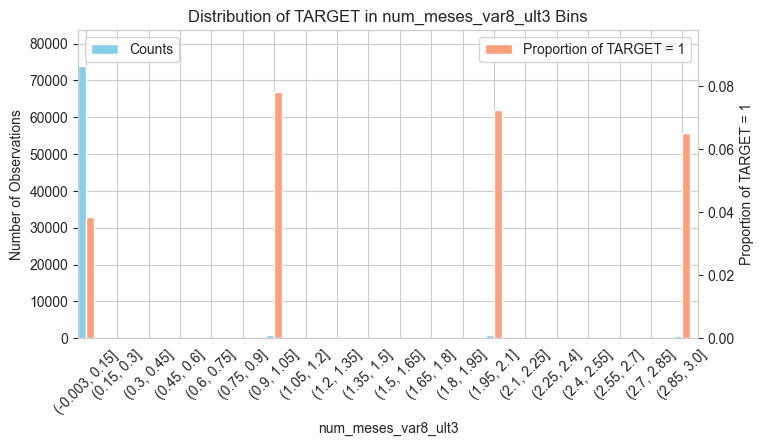

saldo_medio_var12_hace2 distribution:


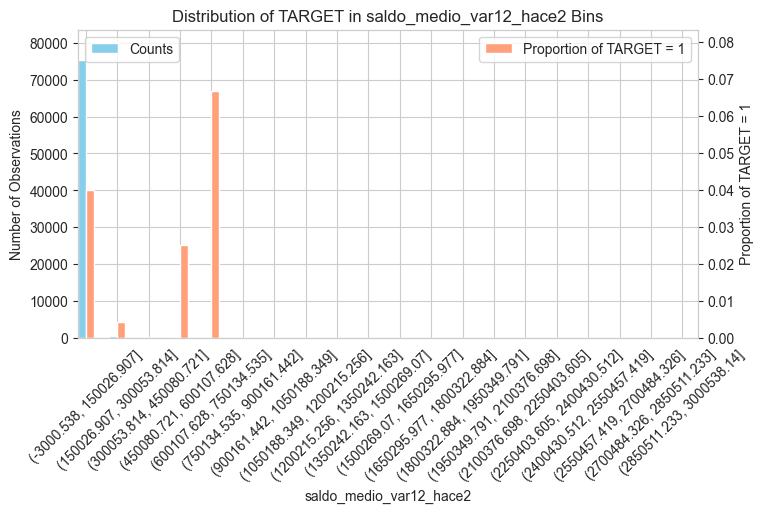

saldo_var24 distribution:


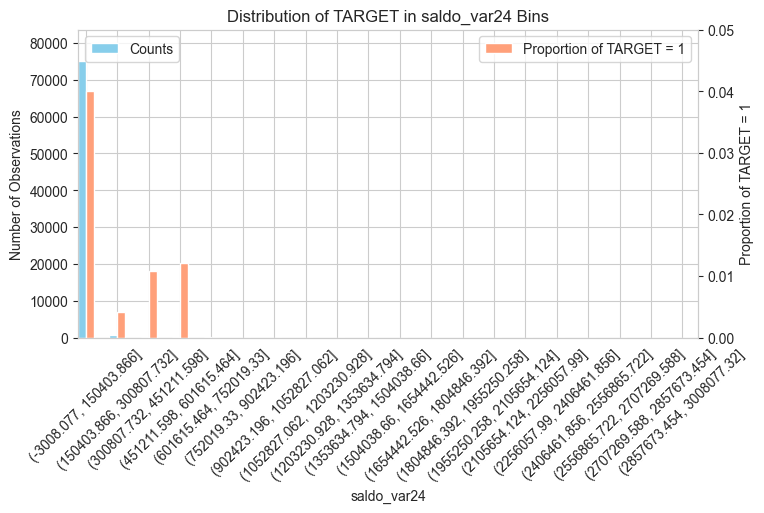

num_var30_0 distribution:


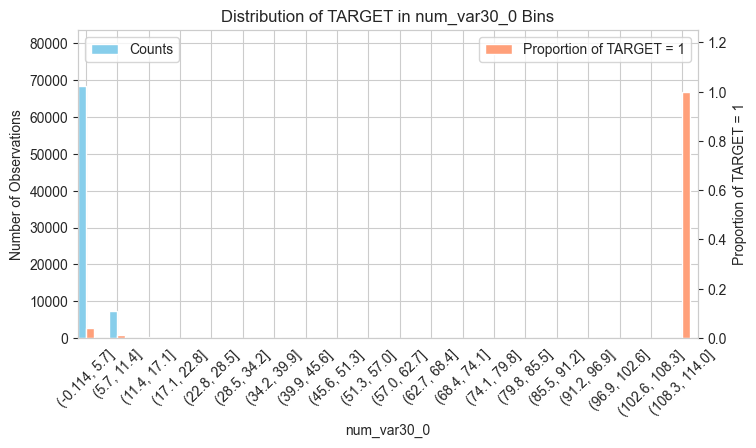

num_var22_ult1 distribution:


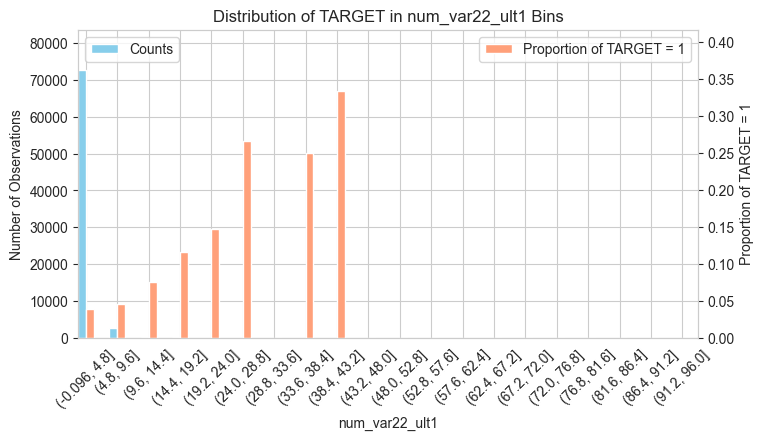

num_op_var39_efect_ult1 distribution:


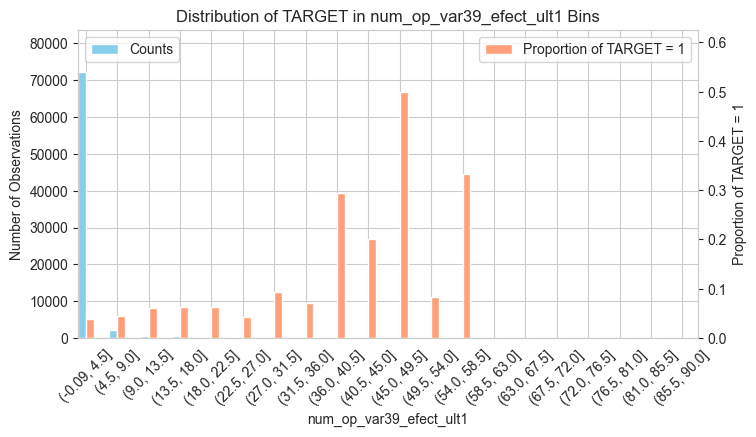

saldo_medio_var13_corto_ult1 distribution:


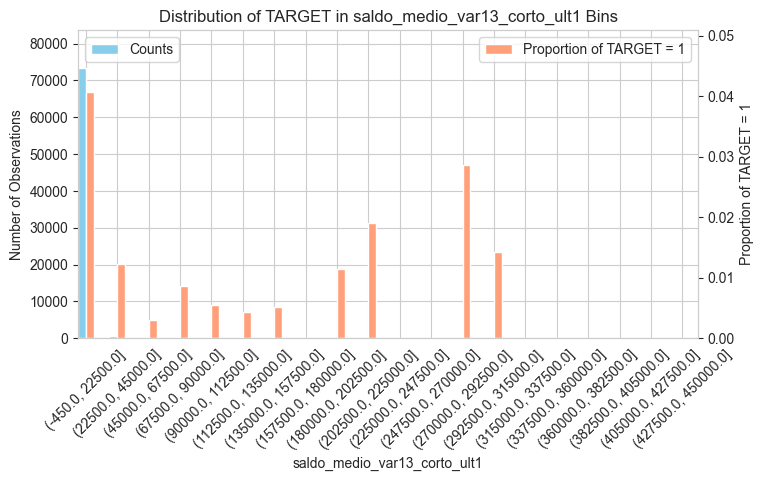

saldo_medio_var13_corto_hace2 distribution:


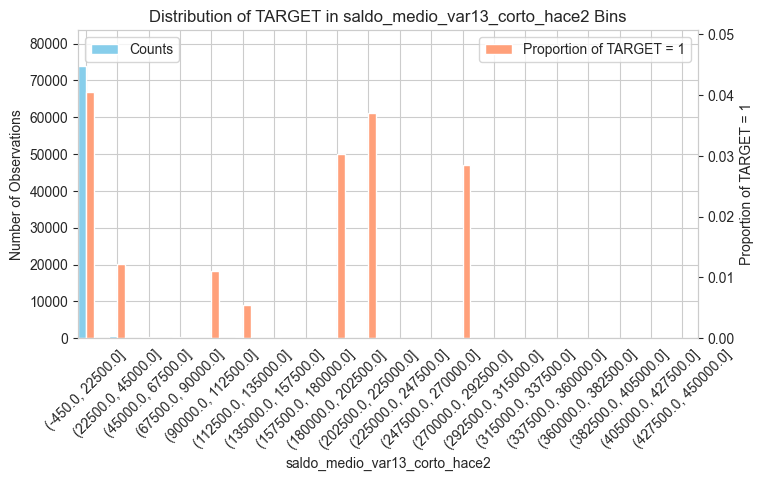

ind_var5_0 distribution:


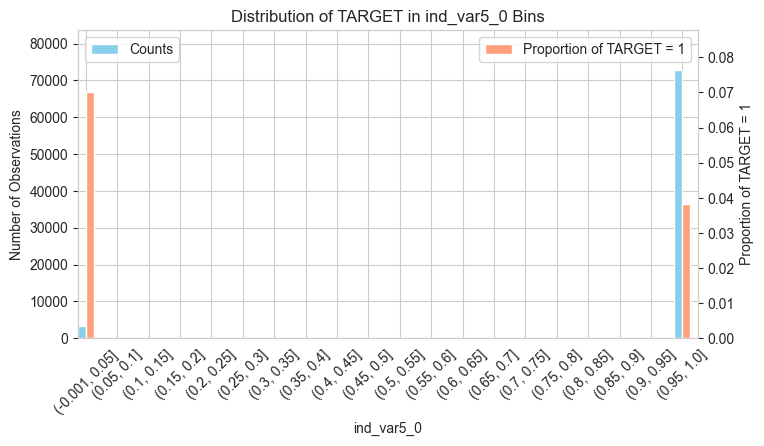

ind_var24 distribution:


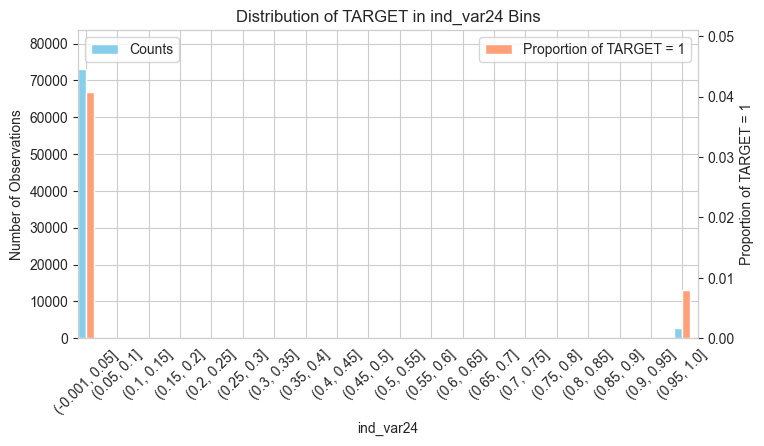

In [ ]:
for imp_feat_item in loaded_cols_phik_5p_Series.index.to_list():
    print(imp_feat_item + " distribution:")
    plot_target_distribution(df_train, imp_feat_item, 'TARGET', bins=20)

saldo_medio_var5_ult3 distribution:


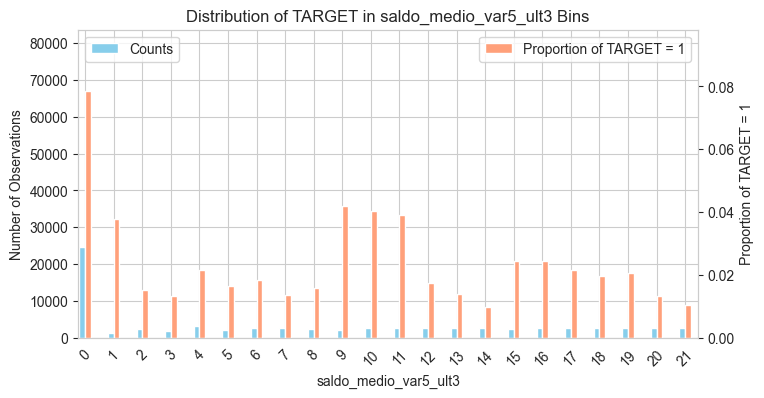

saldo_medio_var5_hace3 distribution:


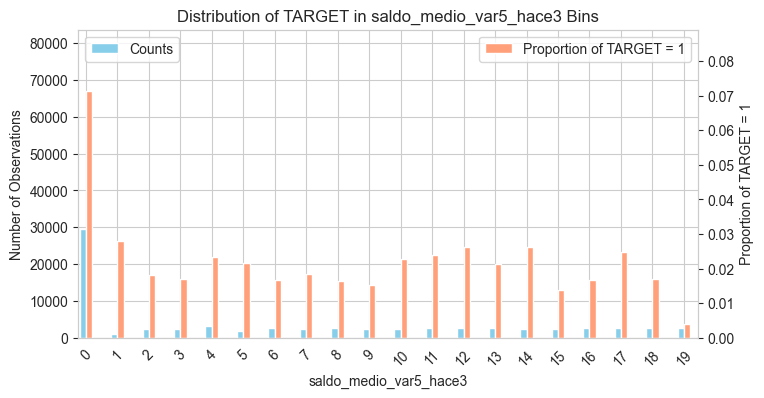

saldo_var30 distribution:


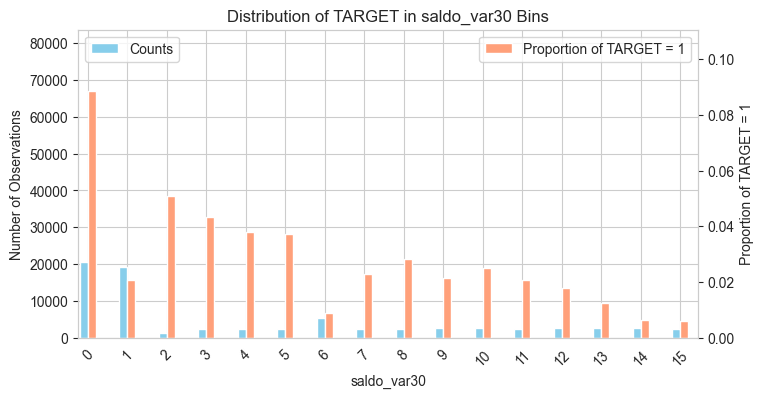

var15 distribution:


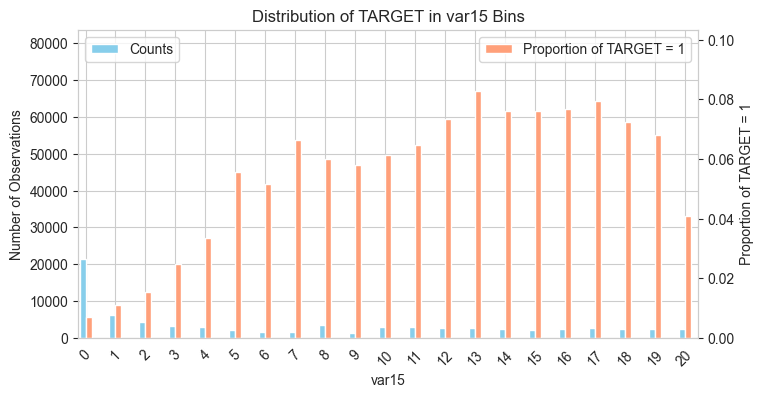

num_var30 distribution:


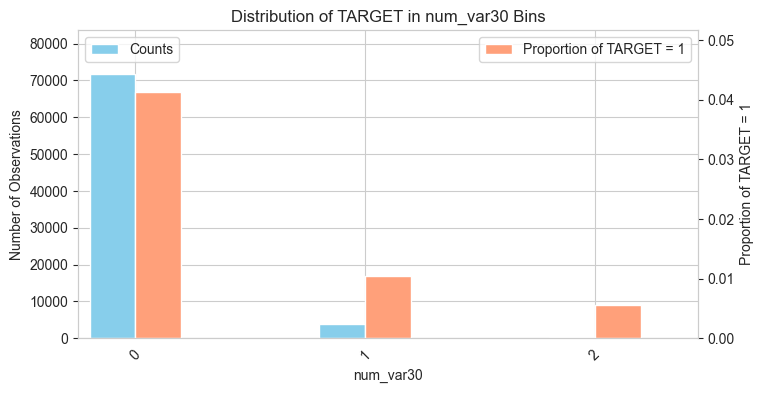

saldo_medio_var5_hace2 distribution:


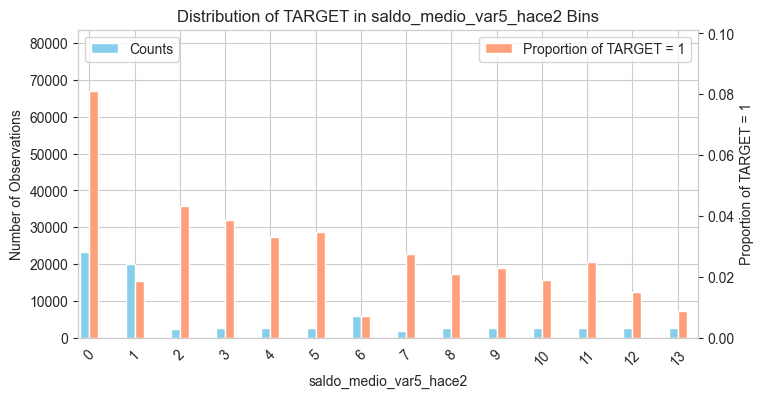

num_var42 distribution:


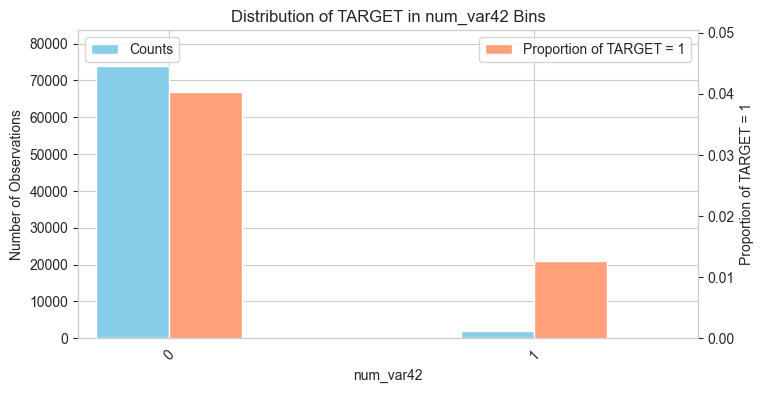

saldo_var5 distribution:


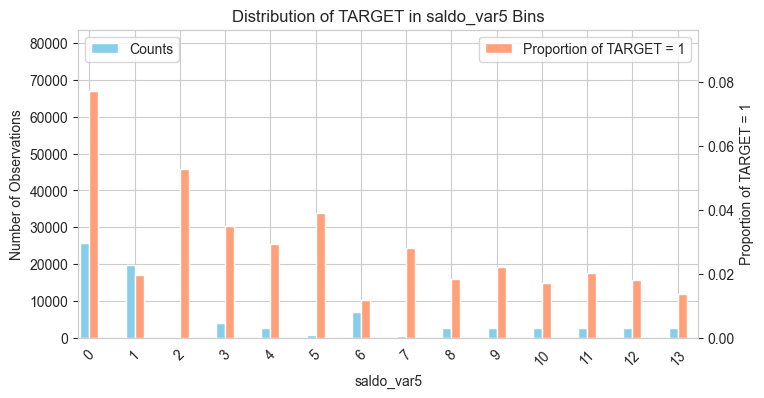

saldo_medio_var5_ult1 distribution:


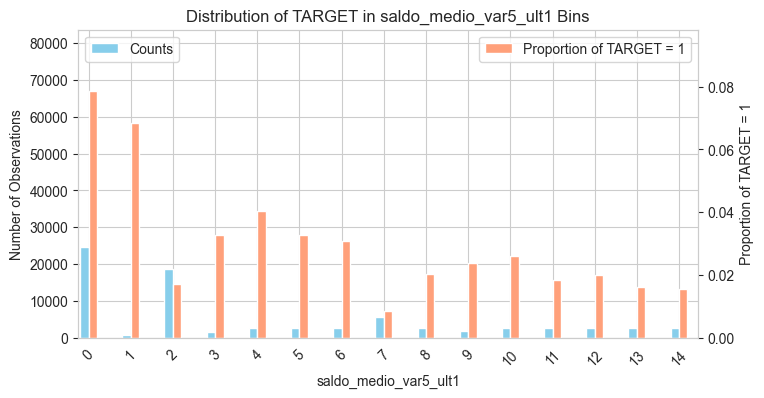

num_var5 distribution:


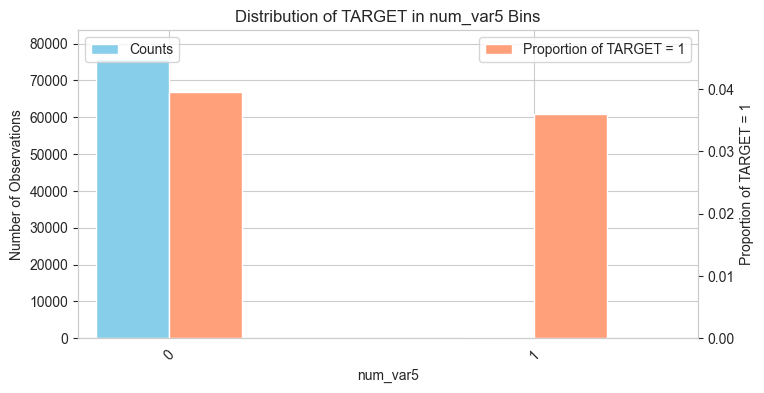

var38 distribution:


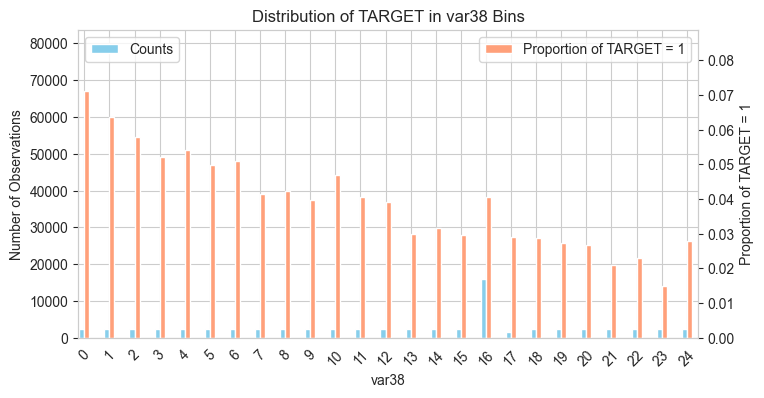

num_var12_0 distribution:


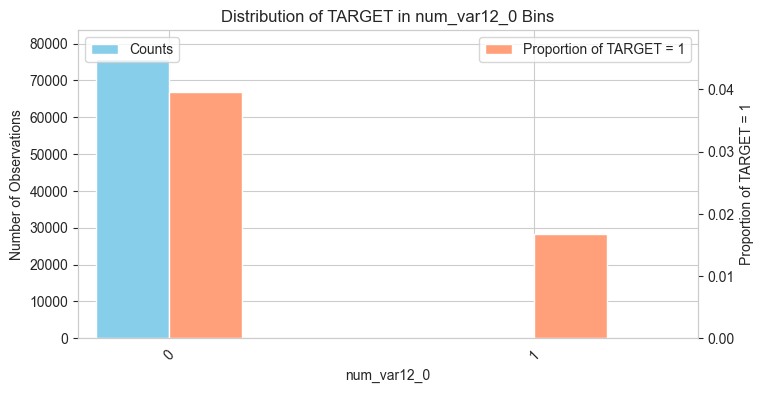

saldo_var13 distribution:


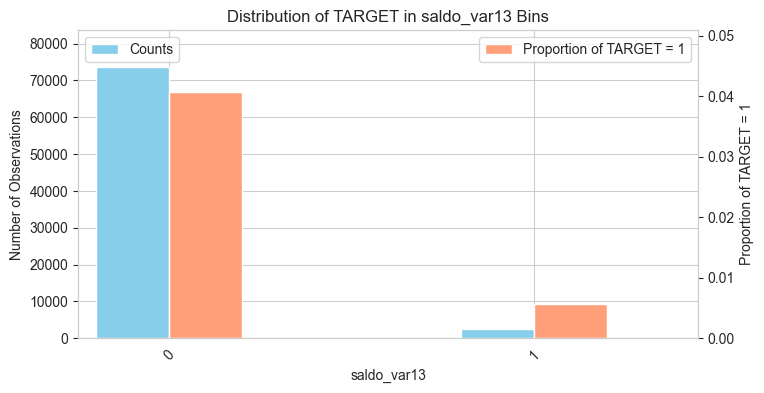

num_var24_0 distribution:


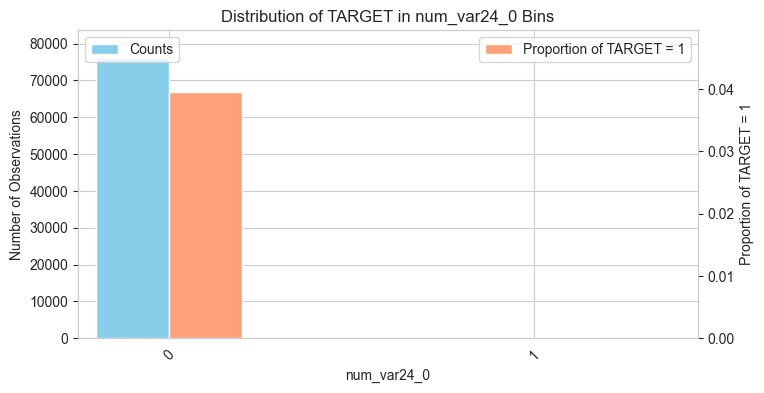

num_var42_0 distribution:


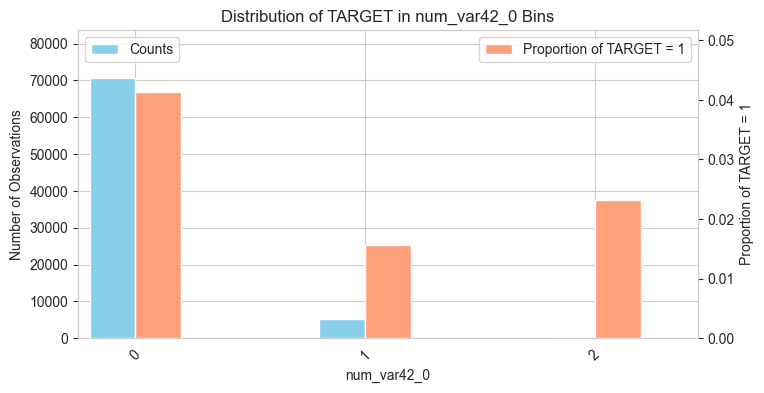

num_var12 distribution:


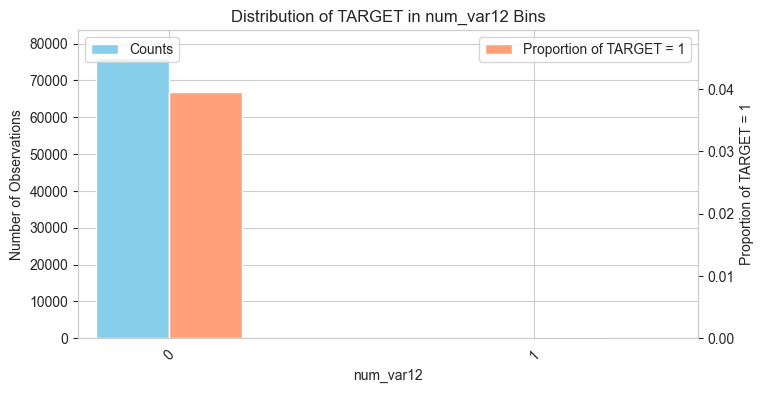

num_var45_ult1 distribution:


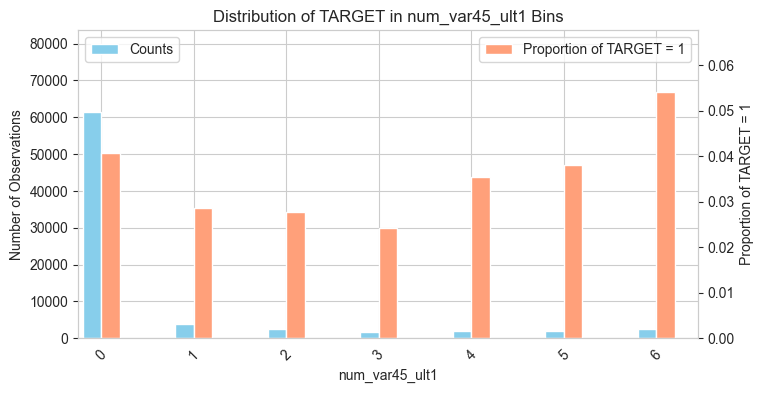

saldo_medio_var12_hace2 distribution:


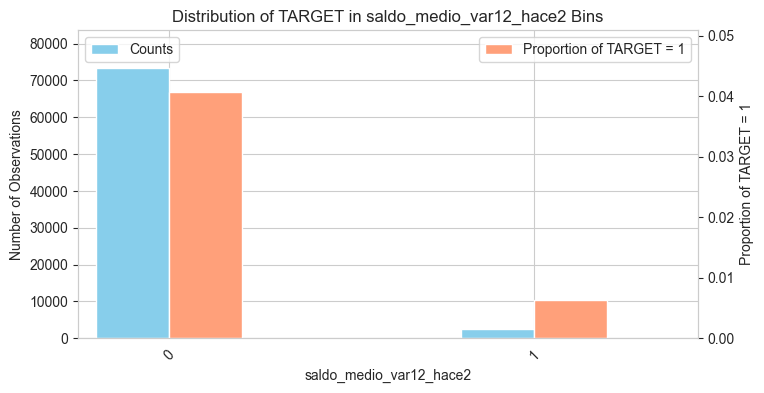

saldo_var24 distribution:


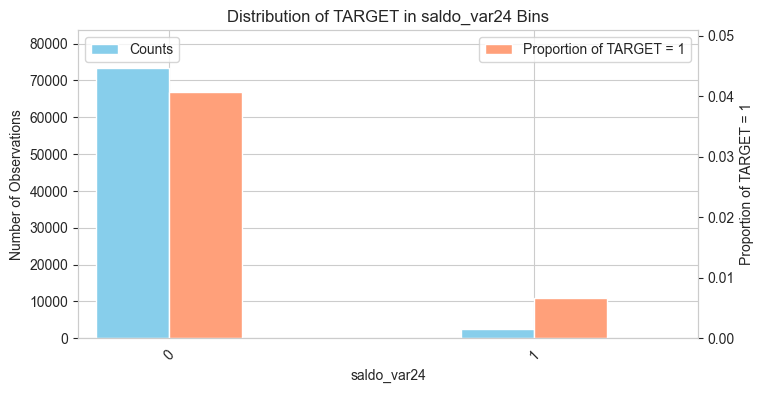

num_var30_0 distribution:


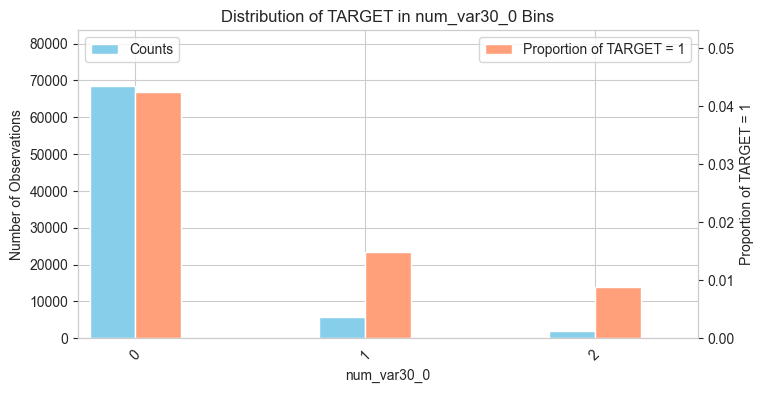

num_var22_ult1 distribution:


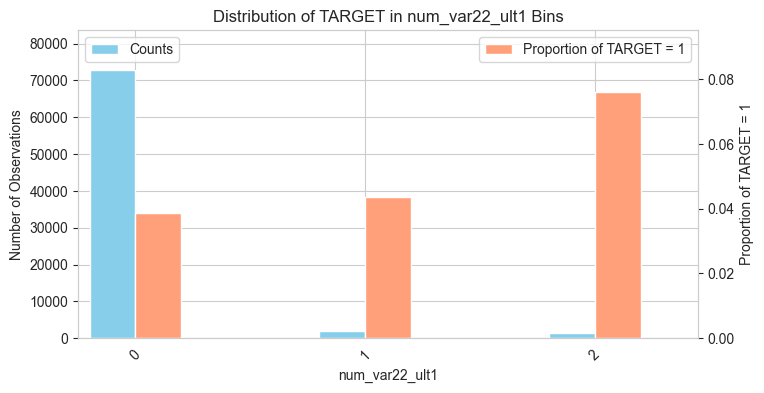

num_op_var39_efect_ult1 distribution:


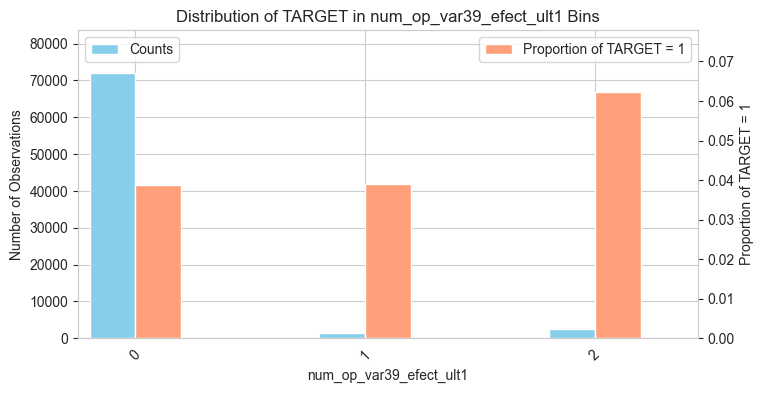

saldo_medio_var13_corto_ult1 distribution:


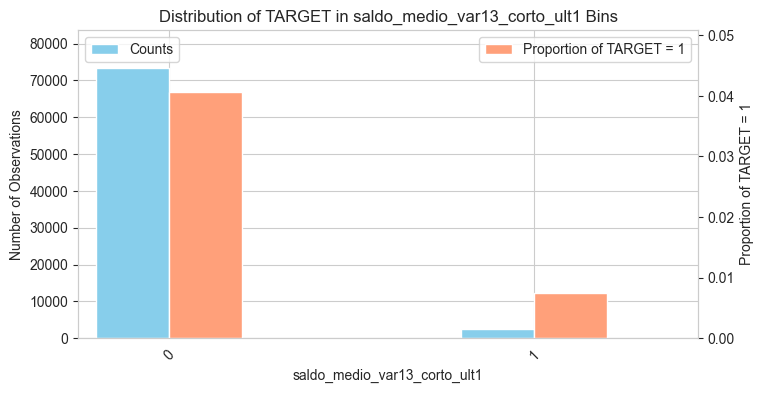

saldo_medio_var13_corto_hace2 distribution:


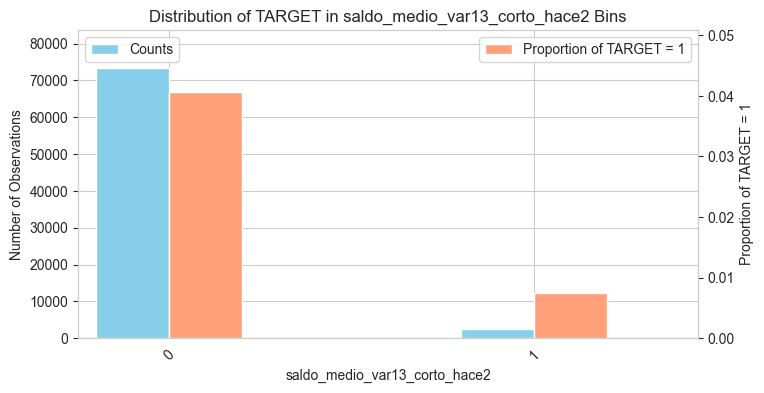

In [ ]:
for imp_feat_item in loaded_cols_phik_5p_Series.index.to_list():
    if imp_feat_item in interval_cols:
        print(imp_feat_item + " distribution:")
        plot_target_distribution_equal(df_train, imp_feat_item, 'TARGET', bins=30)